## AI-Based Job Matching and Compatibility Analysis System — V2

**Key Upgrade over V1:**
V1 embedded the entire resume as a single vector — a 2-page resume averaged into 384 numbers loses most signal.
V2 splits the resume into overlapping semantic chunks, embeds each separately, and takes the **max similarity** across chunks against each job description. This gives each section of the resume its own voice in the matching process.

**System Architecture:**
1. Resume Processing Layer
2. Chunked Resume Embedding (V2 upgrade)
3. Job Filtering Layer
4. Max-Pooled Semantic Retrieval
5. Bidirectional Skill Analysis
6. Scoring and Classification Layer
7. Explainable Output Generation
8. Visual Analytics

### Step 1: Install Dependencies

In [1]:
!pip install -q sentence-transformers scikit-learn pdfplumber gdown wordcloud seaborn

import warnings
warnings.filterwarnings("ignore")

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from matplotlib.patches import Patch
import pdfplumber
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("All dependencies loaded.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 31.9 MB/s eta 0:00:00
All dependencies loaded.


### Step 2: Download and Load Dataset

In [2]:
!gdown https://drive.google.com/uc?id=1ngtq7gCLDqmVHHCKzrM_uhUjImlxObvd

df = pd.read_csv(
    "postings.csv",
    nrows=25000,
    engine="python",
    on_bad_lines="skip"
)

df = df.dropna(subset=["description", "title"])
before = df.shape[0]
df = df.drop_duplicates(subset=["title", "description"])
after = df.shape[0]

print(f"Dataset loaded: {after} jobs ({before - after} duplicates removed)")
df[["title", "company_name", "location", "formatted_experience_level", "application_url"]].head(3)

Downloading...
From (original): https://drive.google.com/uc?id=1ngtq7gCLDqmVHHCKzrM_uhUjImlxObvd
From (redirected): https://drive.google.com/uc?id=1ngtq7gCLDqmVHHCKzrM_uhUjImlxObvd&confirm=t&uuid=f8abb0eb-fb23-4e28-b7c0-ec121fb6bb5b
To: /content/postings.csv
100% 517M/517M [00:03<00:00, 152MB/s]
Dataset loaded: 22745 jobs (2253 duplicates removed)


,title,company_name,location,formatted_experience_level,application_url
0,Marketing Coordinator,Corcoran Sawyer Smith,"Princeton, NJ",NaN,NaN
1,Mental Health Therapist/Counselor,NaN,"Fort Collins, CO",NaN,NaN
2,Assitant Restaurant Manager,The National Exemplar,"Cincinnati, OH",NaN,NaN


### Step 3: Resume Upload and Text Extraction

In [3]:
from google.colab import files

print("Upload your resume PDF:")
uploaded = files.upload()
resume_filename = list(uploaded.keys())[0]
print(f"Uploaded: {resume_filename}")

Upload your resume PDF:


Saving Prudhvi_Resume (1).pdf to Prudhvi_Resume (1).pdf
Uploaded: Prudhvi_Resume (1).pdf


In [4]:
with pdfplumber.open(resume_filename) as pdf:
    resume_text = ""
    for page in pdf.pages:
        extracted = page.extract_text()
        if extracted:
            resume_text += extracted + "\n"

resume_text_lower = resume_text.lower()
print("Resume preview (first 500 chars):")
print(resume_text[:500])

Resume preview (first 500 chars):
Abhishek Bachan
+91 9391234567 | abhishek.bachan@gmail.com | linkedin.com/in/abhishekbachan
github.com/abhishek
SUMMARY
Accomplished Software Engineer with hands-on experience designing and delivering scalable web applications.
Intermediate in building robust back-end services using Java, MySQL, and RESTful APIs, alongside proficiency in Python
and C++. Skilled in cloud-native development on AWS. Adept at crafting responsive front-end interfaces with React.js,
HTML, CSS, and JavaScript, and comm


### Step 3B: Skill Extraction and Experience Detection

In [5]:
skill_keywords = [
    # Programming
    "python", "java", "c++", "sql", "javascript", "typescript", "r", "scala", "go", "rust",
    # AI / ML
    "machine learning", "deep learning", "nlp", "computer vision", "data science",
    "tensorflow", "pytorch", "keras", "scikit-learn", "xgboost", "hugging face",
    "reinforcement learning", "neural network", "transformers", "bert", "llm",
    # Web
    "react", "node", "html", "css", "django", "flask", "fastapi", "angular", "vue",
    # Cloud / DevOps
    "aws", "azure", "gcp", "docker", "kubernetes", "ci/cd", "git", "linux",
    # Data tools
    "pandas", "numpy", "power bi", "tableau", "spark", "hadoop", "airflow",
    "mongodb", "postgresql", "mysql", "redis", "elasticsearch",
    # Other
    "blockchain", "solidity", "cybersecurity", "rest api", "graphql",
    "agile", "scrum", "data engineering", "mlops", "statistics"
]

resume_skills = [skill for skill in skill_keywords if skill in resume_text_lower]
print(f"Skills extracted: {len(resume_skills)}")
print(resume_skills)

# Experience detection
resume_experience_level = "Entry-Level"
year_matches = re.findall(r'(\d+)\+?\s*year', resume_text_lower)
if year_matches:
    max_exp = max(int(y) for y in year_matches)
    if max_exp >= 7:   resume_experience_level = "Principal/Manager"
    elif max_exp >= 5: resume_experience_level = "Senior"
    elif max_exp >= 2: resume_experience_level = "Mid-Level"
    print(f"Years detected: {max_exp} -> {resume_experience_level}")
else:
    if "senior" in resume_text_lower or "lead" in resume_text_lower:
        resume_experience_level = "Senior"
    elif "intern" in resume_text_lower or "student" in resume_text_lower:
        resume_experience_level = "Entry-Level"
    print(f"Keyword fallback -> {resume_experience_level}")

Skills extracted: 23
['python', 'java', 'c++', 'sql', 'javascript', 'r', 'scala', 'go', 'machine learning', 'deep learning', 'nlp', 'computer vision', 'react', 'html', 'css', 'flask', 'aws', 'azure', 'git', 'linux', 'mysql', 'agile', 'data engineering']
Keyword fallback -> Entry-Level


### Step 4: Chunked Resume Embedding (V2 Core Upgrade)

**V1 approach:** Embed entire resume as one vector. A 2-page resume averaged into 384 numbers loses signal — your skills section gets diluted by your address, education header, and generic text.

**V2 approach:** Split resume into overlapping 200-word chunks. Embed each chunk separately. For each job, compute similarity against every chunk and take the **maximum**. This means if your Skills section is a perfect match for a job, that score is captured cleanly without dilution.

In [6]:
def chunk_text(text, chunk_size=200, overlap=50):
    """Split text into overlapping word-level chunks."""
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunk = " ".join(words[start:end])
        if len(chunk.strip()) > 20:
            chunks.append(chunk)
        start += chunk_size - overlap
    return chunks

# Load model
model = SentenceTransformer("all-MiniLM-L6-v2")

# V1: single resume embedding
resume_embedding_v1 = model.encode(resume_text)

# V2: chunked
resume_chunks = chunk_text(resume_text, chunk_size=200, overlap=50)
print(f"Resume split into {len(resume_chunks)} chunks:")
for i, chunk in enumerate(resume_chunks):
    print(f"  Chunk {i+1} ({len(chunk.split())} words): '{chunk[:70]}...'")

resume_chunk_embeddings = model.encode(resume_chunks)
print(f"\nChunk embeddings shape: {resume_chunk_embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Resume split into 4 chunks:
  Chunk 1 (200 words): 'Abhishek Bachan +91 9391234567 | abhishek.bachan@gmail.com | linkedin....'
  Chunk 2 (200 words): 'Data structures, Object Oriented Programming. Certifications: Microsof...'
  Chunk 3 (156 words): '[Link] ● Developed a Recommendation System using 8,000+ titles, employ...'
  Chunk 4 (6 words): 'AI to solve real world problem....'

Chunk embeddings shape: (4, 384)


### Step 4B: Job Embedding and Max-Pooled Similarity Computation

In [7]:
df_sample = df.sample(n=20000, random_state=42)
job_texts = df_sample["description"].tolist()

print("Encoding 20,000 job descriptions...")
job_embeddings = model.encode(job_texts, show_progress_bar=True, batch_size=64)

# V1: single vector similarity
v1_similarities = cosine_similarity([resume_embedding_v1], job_embeddings)[0]

# V2: chunk vs all jobs -> max across chunks per job
# Shape: (num_chunks, num_jobs)
chunk_similarities = cosine_similarity(resume_chunk_embeddings, job_embeddings)
v2_similarities = chunk_similarities.max(axis=0)  # max pooling

improvement = v2_similarities - v1_similarities
print(f"\nV1 Avg Semantic: {v1_similarities.mean():.4f}  Max: {v1_similarities.max():.4f}")
print(f"V2 Avg Semantic: {v2_similarities.mean():.4f}  Max: {v2_similarities.max():.4f}")
print(f"Jobs improved:   {(improvement > 0).sum()} / 20000")
print(f"Avg improvement: {improvement.mean():+.4f}")

Encoding 20,000 job descriptions...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]


V1 Avg Semantic: 0.2215  Max: 0.6596
V2 Avg Semantic: 0.2567  Max: 0.6770
Jobs improved:   16804 / 20000
Avg improvement: +0.0352


### Step 4C: Requirements-Only JD Extraction (V2 Signal Upgrade)

**Problem:** Job descriptions are 80% noise — culture text, benefits, equal opportunity statements.
Matching a resume against this dilutes semantic signal.

**Fix:** Extract only sentences containing requirement signals: 'must', 'required', 'proficient',
'experience', 'preferred', 'minimum'. Match resume against clean requirements only.

In [8]:
import re

REQUIREMENT_SIGNALS = [
    'must', 'required', 'require', 'proficient', 'experience',
    'preferred', 'minimum', 'qualification', 'need', 'should have',
    'responsible', 'you will', 'ability to', 'knowledge of',
    'familiarity', 'strong', 'proven', 'demonstrated'
]

def extract_requirements(jd_text, min_sentences=3):
    if not isinstance(jd_text, str) or len(jd_text.strip()) == 0:
        return jd_text
    sentences = re.split(r'[.\n]', jd_text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
    req_sentences = [
        s for s in sentences
        if any(sig in s.lower() for sig in REQUIREMENT_SIGNALS)
    ]
    if len(req_sentences) < min_sentences:
        return jd_text
    return '. '.join(req_sentences)

job_texts_full = df_sample['description'].fillna('').tolist()
job_texts_req  = [extract_requirements(jd) for jd in job_texts_full]

full_lengths = [len(t.split()) for t in job_texts_full]
req_lengths  = [len(t.split()) for t in job_texts_req]
reduction    = (1 - sum(req_lengths) / sum(full_lengths)) * 100

print(f'Avg JD length — Full: {int(sum(full_lengths)/len(full_lengths))} words')
print(f'Avg JD length — Req:  {int(sum(req_lengths)/len(req_lengths))} words')
print(f'Noise reduction: {reduction:.1f}% of text removed')
print('\n' + '='*60)
print('SAMPLE JD — FULL TEXT (first 400 chars):')
print('-'*60)
print(job_texts_full[0][:400])
print('\n' + '='*60)
print('SAMPLE JD — REQUIREMENTS ONLY:')
print('-'*60)
print(job_texts_req[0][:400])


Avg JD length — Full: 501 words
Avg JD length — Req:  212 words
Noise reduction: 57.6% of text removed

SAMPLE JD — FULL TEXT (first 400 chars):
------------------------------------------------------------

Liberty Cares
With Compassion

****$10,000 SIGN ON BONUS!****
At Liberty Healthcare and Rehabilitation Services, we promote a challenging, but rewarding opportunity in a caring environment. 
We are currently seeking an experienced:

REGISTERED NURSE (RN)

Full Time, Days
Job Description: Assure quality nursing care for patient by following physician’s orders, state and federal regulations and thi

SAMPLE JD — REQUIREMENTS ONLY:
------------------------------------------------------------
We are currently seeking an experienced:. Assists physicians with rounds as needed. Job Requirements: Registered Nurse, graduated from an accredited School of Nursing. Attend in-service training and other staff meetings as required. Ability to supervise nursing assistants assuring that work assignme

### Step 4D: Embed Requirements-Only JDs and Compare All Variants

In [9]:
print('Encoding requirements-only job descriptions...')
job_embeddings_req = model.encode(job_texts_req, show_progress_bar=True, batch_size=64)

# V1r: single vector vs req-only JDs
v1_req_similarities = cosine_similarity([resume_embedding_v1], job_embeddings_req)[0]

# V2r: chunked resume vs req-only JDs (final best)
chunk_sim_req = cosine_similarity(resume_chunk_embeddings, job_embeddings_req)
v2_req_similarities = chunk_sim_req.max(axis=0)

print(f'\nV1  (full JD  + single vector): {v1_similarities.mean():.4f}')
print(f'V1r (req only + single vector): {v1_req_similarities.mean():.4f}')
print(f'V2  (full JD  + chunked):       {v2_similarities.mean():.4f}')
print(f'V2r (req only + chunked):       {v2_req_similarities.mean():.4f}')
print(f'\nFinal improvement V1 -> V2r: {(v2_req_similarities - v1_similarities).mean():+.4f} per job')
print(f'Jobs improved: {(v2_req_similarities > v1_similarities).sum()} / {len(v1_similarities)}')


Encoding requirements-only job descriptions...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]


V1  (full JD  + single vector): 0.2215
V1r (req only + single vector): 0.2443
V2  (full JD  + chunked):       0.2567
V2r (req only + chunked):       0.2785

Final improvement V1 -> V2r: +0.0570 per job
Jobs improved: 16092 / 20000


### Step 5: Bidirectional Skill Scoring

In [10]:
df_sample = df_sample.copy()
df_sample['semantic_score_v1']  = v1_similarities
df_sample['semantic_score_v1r'] = v1_req_similarities
df_sample['semantic_score_v2']  = v2_similarities
df_sample['semantic_score']     = v2_req_similarities

top_jobs = df_sample.sort_values(by='semantic_score', ascending=False).copy()
top_jobs['description_lower'] = top_jobs['description'].fillna('').astype(str).str.lower()

def compute_skill_match(job_text, resume_skills):
    if not job_text or not resume_skills:
        return 0.0, [], list(resume_skills)
    matched = [s for s in resume_skills if s in job_text]
    missing = [s for s in resume_skills if s not in matched]
    return len(matched) / len(resume_skills), matched, missing

top_jobs['skill_coverage'], top_jobs['matched_skills'], top_jobs['missing_skills'] = zip(
    *top_jobs['description_lower'].apply(lambda x: compute_skill_match(x, resume_skills))
)
top_jobs['skill_coverage'] = top_jobs['skill_coverage'].astype(float)

def extract_job_skills(job_text, skill_keywords):
    if not isinstance(job_text, str):
        return []
    return [s for s in skill_keywords if s in job_text]

def compute_job_coverage(job_skills, resume_skills):
    if not job_skills:
        return 0.0, []
    matched = [s for s in job_skills if s in resume_skills]
    missing_required = [s for s in job_skills if s not in resume_skills]
    return len(matched) / len(job_skills), missing_required

top_jobs['job_skills'] = top_jobs['description_lower'].apply(
    lambda x: extract_job_skills(x, skill_keywords)
)
top_jobs['job_coverage'], top_jobs['missing_required_skills'] = zip(
    *top_jobs['job_skills'].apply(lambda x: compute_job_coverage(x, resume_skills))
)
print('Bidirectional skill scoring complete.')


Bidirectional skill scoring complete.


### Step 6: Final Scoring and Fit Classification

In [11]:
def experience_penalty(job_exp):
    job_exp = str(job_exp).lower()
    if 'manager' in job_exp or 'principal' in job_exp: return -0.25
    if 'senior' in job_exp or 'lead' in job_exp:       return -0.15
    if 'entry' in job_exp or 'associate' in job_exp or 'junior' in job_exp: return 0.05
    return 0

top_jobs['exp_penalty'] = top_jobs['formatted_experience_level'].apply(experience_penalty)

top_jobs['v1_score'] = (
    0.4 * top_jobs['semantic_score_v1'] +
    0.3 * top_jobs['skill_coverage'] +
    0.3 * top_jobs['job_coverage'] +
    top_jobs['exp_penalty']
)
top_jobs['v1r_score'] = (
    0.4 * top_jobs['semantic_score_v1r'] +
    0.3 * top_jobs['skill_coverage'] +
    0.3 * top_jobs['job_coverage'] +
    top_jobs['exp_penalty']
)
top_jobs['v2_score'] = (
    0.4 * top_jobs['semantic_score_v2'] +
    0.3 * top_jobs['skill_coverage'] +
    0.3 * top_jobs['job_coverage'] +
    top_jobs['exp_penalty']
)
top_jobs['final_score'] = (
    0.4 * top_jobs['semantic_score'] +
    0.3 * top_jobs['skill_coverage'] +
    0.3 * top_jobs['job_coverage'] +
    top_jobs['exp_penalty']
)

top_jobs = top_jobs.sort_values(by='final_score', ascending=False).copy()

mean_score = top_jobs['final_score'].mean()
std_score  = top_jobs['final_score'].std()
v1_mean    = top_jobs['v1_score'].mean()
v1_std     = top_jobs['v1_score'].std()

def classify_fit(score, mean, std):
    if score >= mean + 0.5 * std: return 'Strong Fit'
    elif score >= mean - 0.5 * std: return 'Moderate Fit'
    else: return 'Weak Fit'

top_jobs['fit_category'] = top_jobs['final_score'].apply(lambda s: classify_fit(s, mean_score, std_score))
top_jobs['fit_v1']       = top_jobs['v1_score'].apply(lambda s: classify_fit(s, v1_mean, v1_std))

print(f'V1  (full JD  + single vector): Mean={top_jobs["v1_score"].mean():.4f}  Std={top_jobs["v1_score"].std():.4f}')
print(f'V1r (req only + single vector): Mean={top_jobs["v1r_score"].mean():.4f}  Std={top_jobs["v1r_score"].std():.4f}')
print(f'V2  (full JD  + chunked):       Mean={top_jobs["v2_score"].mean():.4f}  Std={top_jobs["v2_score"].std():.4f}')
print(f'V2r (req only + chunked):       Mean={top_jobs["final_score"].mean():.4f}  Std={top_jobs["final_score"].std():.4f}')
print(f'\nFit Distribution (V2r final):')
print(top_jobs['fit_category'].value_counts())


V1  (full JD  + single vector): Mean=0.3640  Std=0.1006
V1r (req only + single vector): Mean=0.3731  Std=0.0991
V2  (full JD  + chunked):       Mean=0.3781  Std=0.1005
V2r (req only + chunked):       Mean=0.3868  Std=0.0995

Fit Distribution (V2r final):
fit_category
Strong Fit      7582
Weak Fit        6551
Moderate Fit    5867
Name: count, dtype: int64


### Step 7: Explainable Ranked Output

In [12]:
def generate_explanation(row):
    matched     = list(row["matched_skills"])
    missing_req = list(row["missing_required_skills"]) if row["missing_required_skills"] else []
    improvement = row["semantic_score"] - row["semantic_score_v1"]

    if row["fit_category"] == "Strong Fit":
        base = f"Strong match. Your skills in {', '.join(matched[:5])} align with this role." if matched \
               else "Strong semantic alignment based on overall profile."
    elif row["fit_category"] == "Moderate Fit":
        base = f"Good alignment. Missing: {', '.join(missing_req[:5])}." if missing_req \
               else "Good alignment, some experience mismatch."
    else:
        base = f"Limited alignment. Key gaps: {', '.join(missing_req[:5])}." if missing_req \
               else "Limited alignment with current skill set."

    chunk_note = f" [Chunk matching boosted semantic by {improvement:+.3f}]" if improvement > 0.01 else ""
    return base + chunk_note

top_jobs["explanation"] = top_jobs.apply(generate_explanation, axis=1)

for i, (_, row) in enumerate(top_jobs.head(10).iterrows(), 1):
    apply_link = row["application_url"] if pd.notna(row["application_url"]) else row.get("job_posting_url", "N/A")
    print("\n" + "=" * 100)
    print(f"Rank {i} | {row['fit_category']}")
    print("-" * 100)
    print(f"Title:    {row['title']}")
    print(f"Company:  {row['company_name']}")
    print(f"Location: {row['location']}")
    print("\nCompatibility Scores")
    print(f"   V2 Final Score:       {round(row['final_score']*100,1)}%  (V1: {round(row['v1_score']*100,1)}%)")
    print(f"   Semantic V1:          {round(row['semantic_score_v1']*100,1)}%")
    print(f"   Semantic V2 (chunk):  {round(row['semantic_score']*100,1)}%  ({row['semantic_score']-row['semantic_score_v1']:+.3f})")
    print(f"   Resume -> Job:        {round(row['skill_coverage']*100,1)}%")
    print(f"   Job -> Resume:        {round(row['job_coverage']*100,1)}%")
    print("\nSkill Analysis")
    print(f"   Matched: {', '.join(list(row['matched_skills'])[:8]) or 'None'}")
    print(f"   Gap:     {', '.join(list(row['missing_required_skills'])[:5]) if row['missing_required_skills'] else 'None'}")
    print(f"\nExplanation: {row['explanation']}")
    print(f"Apply: {apply_link}")


Rank 1 | Strong Fit
----------------------------------------------------------------------------------------------------
Title:    Data Engineer
Company:  Capital One
Location: Richmond, VA

Compatibility Scores
   V2 Final Score:       72.9%  (V1: 63.0%)
   Semantic V1:          37.7%
   Semantic V2 (chunk):  62.3%  (+0.246)
   Resume -> Job:        56.5%
   Job -> Resume:        86.7%

Skill Analysis
   Matched: python, java, sql, r, scala, go, machine learning, aws
   Gap:     spark, hadoop

Explanation: Strong match. Your skills in python, java, sql, r, scala align with this role. [Chunk matching boosted semantic by +0.246]
Apply: https://dsp.prng.co/J9frmab

Rank 2 | Strong Fit
----------------------------------------------------------------------------------------------------
Title:    Software Engineer
Company:  Ascendion
Location: United States

Compatibility Scores
   V2 Final Score:       68.1%  (V1: 57.9%)
   Semantic V1:          37.6%
   Semantic V2 (chunk):  63.3%  (+0.2

### Step 8: Visual Analytics

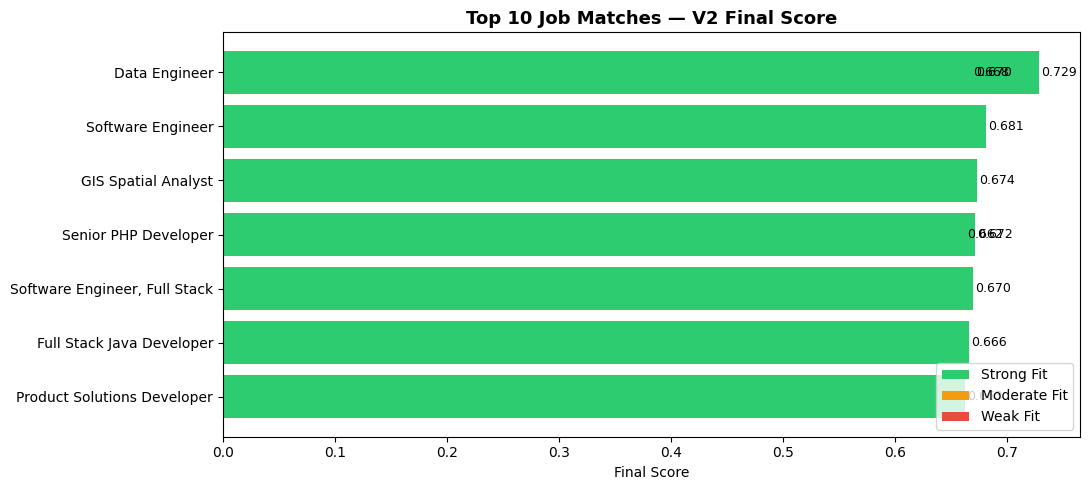

In [13]:
top10 = top_jobs.head(10).copy()
top10["short_title"] = top10["title"].str[:40]

# Chart 1: Top 10 Final Score Bar Chart
plt.figure(figsize=(11, 5))
colors = ['#2ecc71' if f == 'Strong Fit' else '#f39c12' if f == 'Moderate Fit' else '#e74c3c'
          for f in top10['fit_category']]
bars = plt.barh(top10["short_title"], top10["final_score"], color=colors)
for bar, score in zip(bars, top10['final_score']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', fontsize=9)
legend_elements = [Patch(facecolor='#2ecc71', label='Strong Fit'),
                   Patch(facecolor='#f39c12', label='Moderate Fit'),
                   Patch(facecolor='#e74c3c', label='Weak Fit')]
plt.legend(handles=legend_elements, loc='lower right')
plt.title("Top 10 Job Matches — V2 Final Score", fontsize=13, fontweight='bold')
plt.xlabel("Final Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

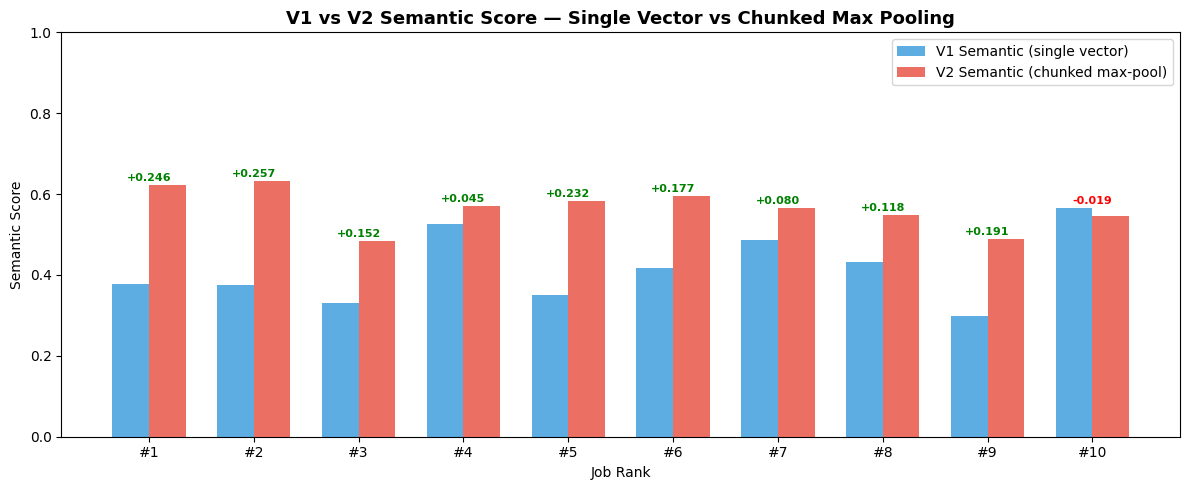

In [14]:
# Chart 2: V1 vs V2 Semantic Score per Top 10 Job
x = np.arange(len(top10))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, top10["semantic_score_v1"], width, label='V1 Semantic (single vector)', color='#3498db', alpha=0.8)
ax.bar(x + width/2, top10["semantic_score"],    width, label='V2 Semantic (chunked max-pool)', color='#e74c3c', alpha=0.8)
for i, (v1, v2) in enumerate(zip(top10['semantic_score_v1'], top10['semantic_score'])):
    diff = v2 - v1
    ax.text(i, max(v1, v2) + 0.01, f'{diff:+.3f}', ha='center', fontsize=8,
            color='green' if diff >= 0 else 'red', fontweight='bold')
ax.set_xlabel('Job Rank')
ax.set_ylabel('Semantic Score')
ax.set_title('V1 vs V2 Semantic Score — Single Vector vs Chunked Max Pooling', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'#{i+1}' for i in range(len(top10))])
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

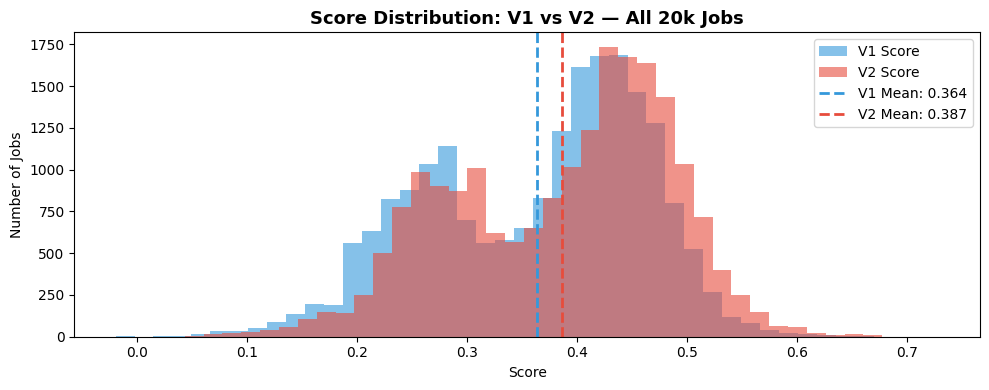

In [15]:
# Chart 3: V1 vs V2 Score Distribution Overlay
plt.figure(figsize=(10, 4))
plt.hist(top_jobs["v1_score"],    bins=40, alpha=0.6, label='V1 Score', color='#3498db')
plt.hist(top_jobs["final_score"], bins=40, alpha=0.6, label='V2 Score', color='#e74c3c')
plt.axvline(v1_mean,    color='#3498db', linestyle='--', linewidth=2, label=f'V1 Mean: {v1_mean:.3f}')
plt.axvline(mean_score, color='#e74c3c', linestyle='--', linewidth=2, label=f'V2 Mean: {mean_score:.3f}')
plt.title('Score Distribution: V1 vs V2 — All 20k Jobs', fontsize=13, fontweight='bold')
plt.xlabel('Score')
plt.ylabel('Number of Jobs')
plt.legend()
plt.tight_layout()
plt.show()

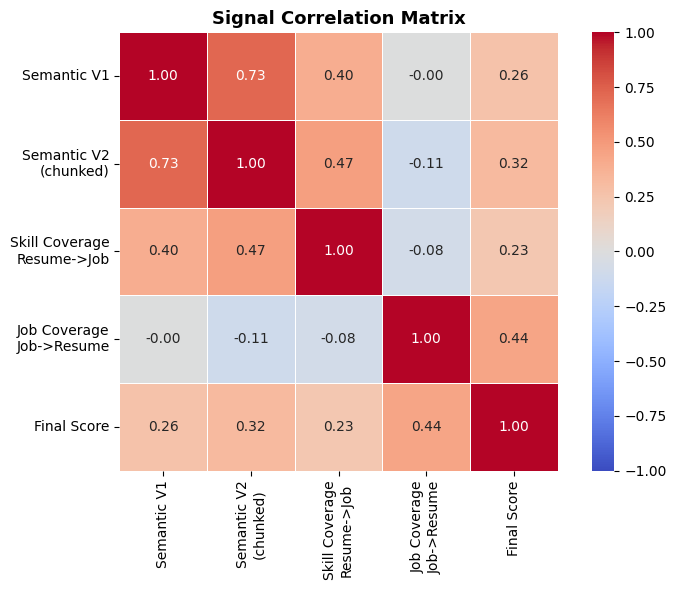

In [16]:
# Chart 4: Signal Correlation Heatmap
signal_cols = ['semantic_score_v1', 'semantic_score', 'skill_coverage', 'job_coverage', 'final_score']
corr = top_jobs[signal_cols].corr()
corr.index = corr.columns = ['Semantic V1', 'Semantic V2\n(chunked)', 'Skill Coverage\nResume->Job', 'Job Coverage\nJob->Resume', 'Final Score']
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Signal Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

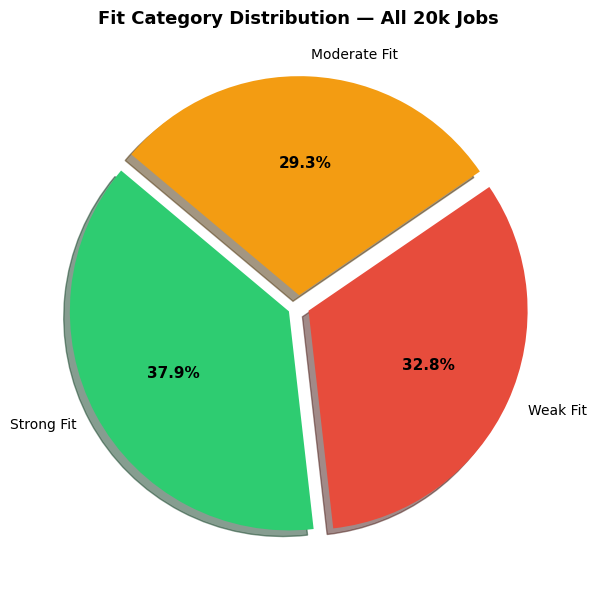

In [17]:
# Chart 5: Fit Category Pie Chart
fit_counts = top_jobs['fit_category'].value_counts()
colors_pie = {'Strong Fit': '#2ecc71', 'Moderate Fit': '#f39c12', 'Weak Fit': '#e74c3c'}
pie_colors = [colors_pie.get(c, '#95a5a6') for c in fit_counts.index]
fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    fit_counts.values, labels=fit_counts.index, colors=pie_colors,
    autopct='%1.1f%%', startangle=140, explode=[0.05]*len(fit_counts), shadow=True
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
ax.set_title('Fit Category Distribution — All 20k Jobs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

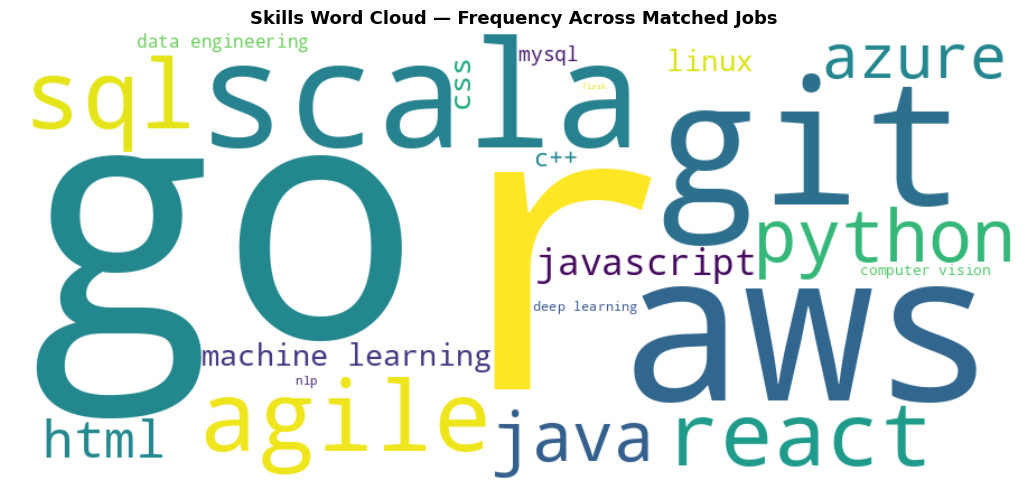

In [18]:
# Chart 6: Skills Word Cloud
all_matched = [s for sublist in top_jobs['matched_skills'] for s in sublist]
skill_freq = Counter(all_matched)
if skill_freq:
    wc = WordCloud(width=900, height=400, background_color='white', colormap='viridis', max_words=60)
    wc.generate_from_frequencies(skill_freq)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Skills Word Cloud — Frequency Across Matched Jobs', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

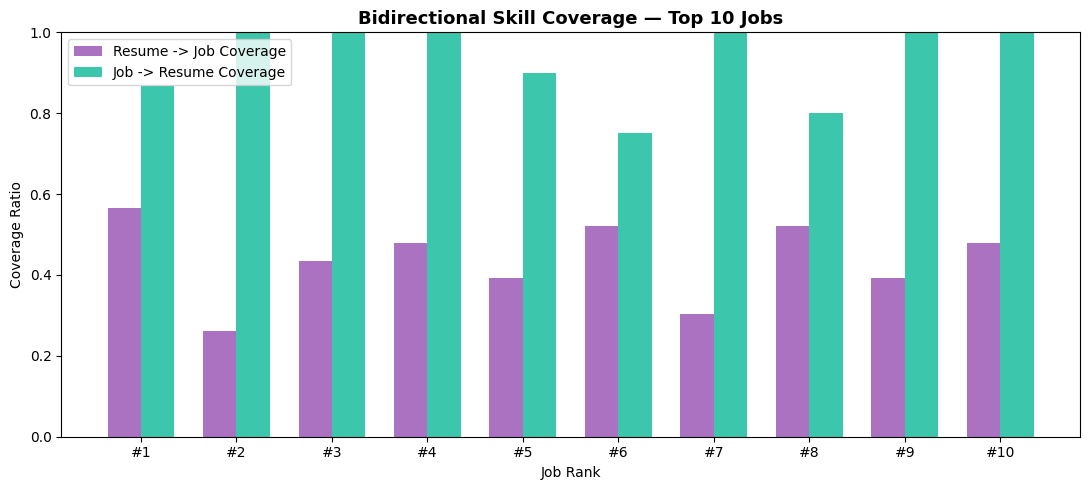

In [19]:
# Chart 7: Bidirectional Skill Coverage — Top 10
x = np.arange(len(top10))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, top10['skill_coverage'], width, label='Resume -> Job Coverage', color='#9b59b6', alpha=0.85)
ax.bar(x + width/2, top10['job_coverage'],   width, label='Job -> Resume Coverage', color='#1abc9c', alpha=0.85)
ax.set_xlabel('Job Rank')
ax.set_ylabel('Coverage Ratio')
ax.set_title('Bidirectional Skill Coverage — Top 10 Jobs', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'#{i+1}' for i in range(len(top10))])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

### Step 9: Skill Gap Summary

Analysed 7582 Strong Fit jobs

-- Top Skills to Upskill In --
  1. rust                      required in 2.7% of Strong Fit jobs
  2. ci/cd                     required in 1.1% of Strong Fit jobs
  3. docker                    required in 1.1% of Strong Fit jobs
  4. scrum                     required in 1.0% of Strong Fit jobs
  5. kubernetes                required in 1.0% of Strong Fit jobs
  6. data science              required in 1.0% of Strong Fit jobs
  7. statistics                required in 0.8% of Strong Fit jobs
  8. spark                     required in 0.7% of Strong Fit jobs
  9. node                      required in 0.7% of Strong Fit jobs
  10. llm                       required in 0.7% of Strong Fit jobs


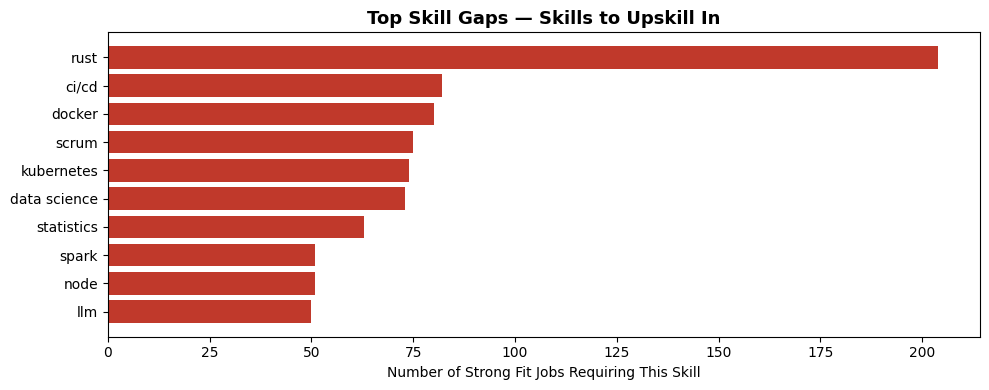

In [20]:
strong_fit_jobs = top_jobs[top_jobs['fit_category'] == 'Strong Fit']
all_missing = [s for sublist in strong_fit_jobs['missing_required_skills'] for s in (sublist if sublist else [])]
gap_counter = Counter(all_missing).most_common(10)

print(f"Analysed {len(strong_fit_jobs)} Strong Fit jobs")
print("\n-- Top Skills to Upskill In --")
for rank, (skill, count) in enumerate(gap_counter, 1):
    pct = round(count / len(strong_fit_jobs) * 100, 1)
    print(f"  {rank}. {skill:<25} required in {pct}% of Strong Fit jobs")

if gap_counter:
    skills_gap, counts_gap = zip(*gap_counter)
    plt.figure(figsize=(10, 4))
    plt.barh(list(skills_gap), list(counts_gap), color='#c0392b')
    plt.xlabel('Number of Strong Fit Jobs Requiring This Skill')
    plt.title('Top Skill Gaps — Skills to Upskill In', fontsize=13, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

### Evolution Chart: V1 -> V1r -> V2 -> V2r

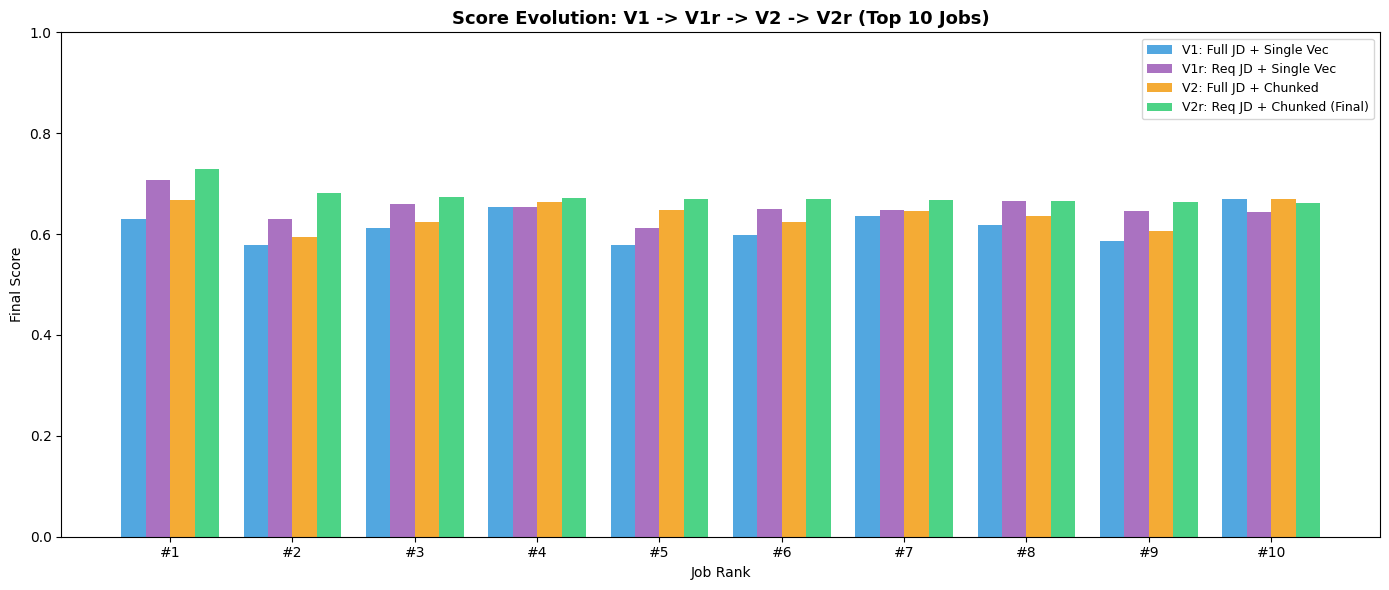

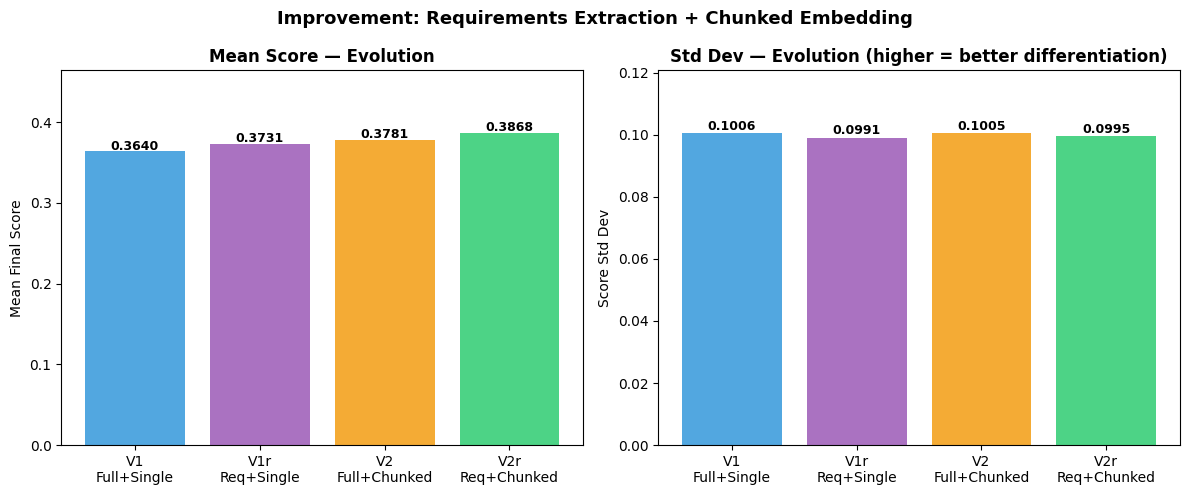

In [21]:
top10 = top_jobs.head(10).copy()
top10['short_title'] = top10['title'].str[:28]

# Chart A: 4-variant grouped bar for top 10
x = np.arange(len(top10))
width = 0.2
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 1.5*width, top10['v1_score'],    width, label='V1: Full JD + Single Vec',      color='#3498db', alpha=0.85)
ax.bar(x - 0.5*width, top10['v1r_score'],   width, label='V1r: Req JD + Single Vec',      color='#9b59b6', alpha=0.85)
ax.bar(x + 0.5*width, top10['v2_score'],    width, label='V2: Full JD + Chunked',         color='#f39c12', alpha=0.85)
ax.bar(x + 1.5*width, top10['final_score'], width, label='V2r: Req JD + Chunked (Final)', color='#2ecc71', alpha=0.85)
ax.set_xlabel('Job Rank')
ax.set_ylabel('Final Score')
ax.set_title('Score Evolution: V1 -> V1r -> V2 -> V2r (Top 10 Jobs)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'#{i+1}' for i in range(len(top10))])
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Chart B: Mean and Std progression
labels = ['V1\nFull+Single', 'V1r\nReq+Single', 'V2\nFull+Chunked', 'V2r\nReq+Chunked']
means  = [top_jobs['v1_score'].mean(), top_jobs['v1r_score'].mean(),
          top_jobs['v2_score'].mean(), top_jobs['final_score'].mean()]
stds   = [top_jobs['v1_score'].std(),  top_jobs['v1r_score'].std(),
          top_jobs['v2_score'].std(),  top_jobs['final_score'].std()]
colors = ['#3498db', '#9b59b6', '#f39c12', '#2ecc71']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.bar(labels, means, color=colors, alpha=0.85)
for i, m in enumerate(means):
    ax1.text(i, m + 0.002, f'{m:.4f}', ha='center', fontsize=9, fontweight='bold')
ax1.set_title('Mean Score — Evolution', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Final Score')
ax1.set_ylim(0, max(means) * 1.2)

ax2.bar(labels, stds, color=colors, alpha=0.85)
for i, s in enumerate(stds):
    ax2.text(i, s + 0.001, f'{s:.4f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Std Dev — Evolution (higher = better differentiation)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score Std Dev')
ax2.set_ylim(0, max(stds) * 1.2)

plt.suptitle('Improvement: Requirements Extraction + Chunked Embedding', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Step 10: V1 vs V2 Quantitative Comparison

In [22]:
v1_strong = (top_jobs['fit_v1'] == 'Strong Fit').sum()
v2_strong = (top_jobs['fit_category'] == 'Strong Fit').sum()

print('=' * 70)
print('         Evolution: V1 -> V1r -> V2 -> V2r')
print('=' * 70)
print(f'{'Variant':<22} {'Approach':<28} {'Mean':>8} {'Std':>8}')
print('-' * 70)

variants = [
    ('V1  (baseline)', 'Full JD + Single Vector',   top_jobs['v1_score'].mean(),    top_jobs['v1_score'].std()),
    ('V1r (req only)', 'Req JD  + Single Vector',   top_jobs['v1r_score'].mean(),   top_jobs['v1r_score'].std()),
    ('V2  (chunked)',  'Full JD + Chunked MaxPool',  top_jobs['v2_score'].mean(),    top_jobs['v2_score'].std()),
    ('V2r (final)',    'Req JD  + Chunked MaxPool',  top_jobs['final_score'].mean(), top_jobs['final_score'].std()),
]
for name, approach, mean, std in variants:
    print(f'{name:<22} {approach:<28} {mean:>8.4f} {std:>8.4f}')

print('=' * 70)
print(f'Noise reduction : {reduction:.1f}% of JD text removed')
print(f'Resume chunks   : {len(resume_chunks)}')
print(f'Strong Fit jobs : V1={v1_strong}  V2r={v2_strong}')
print(f'\nStory:')
print(f'  V1  -> V1r : Effect of requirements extraction alone')
print(f'  V1  -> V2  : Effect of chunked embedding alone')
print(f'  V1  -> V2r : Combined effect — final system')


         Evolution: V1 -> V1r -> V2 -> V2r
Variant                Approach                         Mean      Std
----------------------------------------------------------------------
V1  (baseline)         Full JD + Single Vector        0.3640   0.1006
V1r (req only)         Req JD  + Single Vector        0.3731   0.0991
V2  (chunked)          Full JD + Chunked MaxPool      0.3781   0.1005
V2r (final)            Req JD  + Chunked MaxPool      0.3868   0.0995
Noise reduction : 57.6% of JD text removed
Resume chunks   : 4
Strong Fit jobs : V1=7708  V2r=7582

Story:
  V1  -> V1r : Effect of requirements extraction alone
  V1  -> V2  : Effect of chunked embedding alone
  V1  -> V2r : Combined effect — final system
